In [2]:
import argparse
import os
import sys
import time
from sys import platform

import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3 import PPO, SAC

# from stable_baselines3.common.cmd_util import make_vec_env
from stable_baselines3.common.env_util import (
    make_vec_env,  # fix for newer versions of stable-baselines3
)

# may be helpful depending on your system
# if platform =="darwin": # mac
#   import PyQt5
#   matplotlib.use("Qt5Agg")
# else: # linux
#   matplotlib.use('TkAgg')
# stable-baselines3
from stable_baselines3.common.monitor import load_results
from stable_baselines3.common.vec_env import VecNormalize

# utils
from env.quadruped_gym_env import QuadrupedGymEnv
from utils.file_utils import get_latest_model, load_all_results
from utils.utils import plot_results, extract_results

pybullet build time: Jan 29 2025 23:20:52


In [3]:
log_dir = "/home/moskit/epfl/legged_robots/quadruped_project/trained_models/flat_terrain/fixed_vel_orient_10"

      index            r     l            t
0         0   -35.435136     6     9.866371
1         0   -43.630140     6     9.868729
2         0   -39.715154     6     9.871171
3         0   -39.063738     7    10.365837
4         0   -39.728722     7    10.366127
...     ...          ...   ...          ...
7765    216   -12.295254    15  6651.937979
7766    217   -52.175572    51  6654.818500
7767    218   -31.343238     5  6655.428030
7768    219   -45.994052     5  6656.070213
7769    211  1242.314476  2001  6664.445002

[7770 rows x 4 columns]


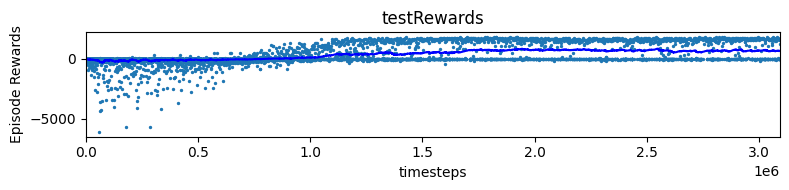

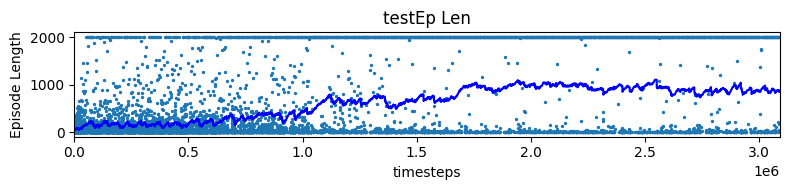

In [4]:
stats_path = os.path.join(log_dir, "vec_normalize.pkl")
model_name = get_latest_model(log_dir)
monitor_results = load_results(log_dir)
print(monitor_results)
plot_results([log_dir] , 10e10, 'timesteps', "test")
plt.show() 

In [5]:
rewards_xy_list, episode_xy_list = extract_results([log_dir] , 10e10, 'timesteps', "test")

In [6]:
x, y = episode_xy_list[0]

In [7]:
def analyse_output(data):
    x, y = data[0]
    # plt.scatter(x, y)
    later_stage = y[5000:]
    print(later_stage.mean())
    plt.violinplot(later_stage)

787.1104693140794


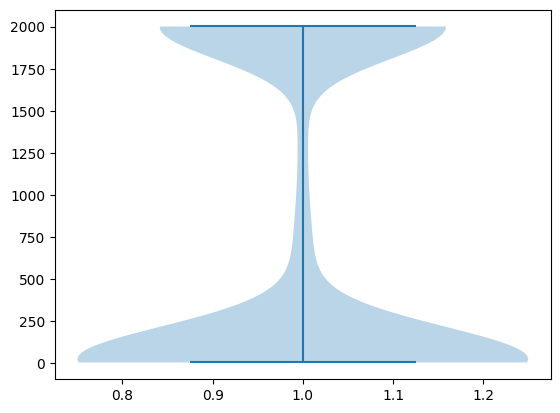

In [8]:
analyse_output(episode_xy_list)

530.5420666830325


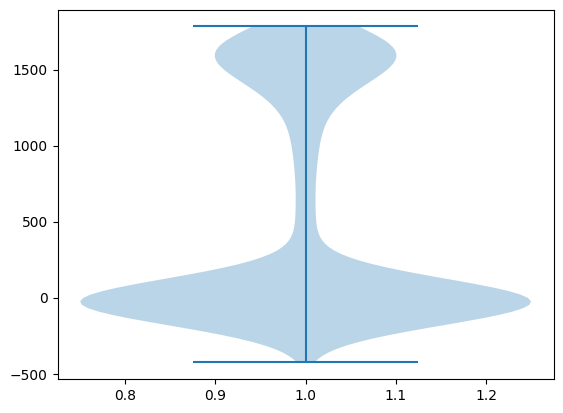

In [9]:
analyse_output(rewards_xy_list)

768.3630903065451


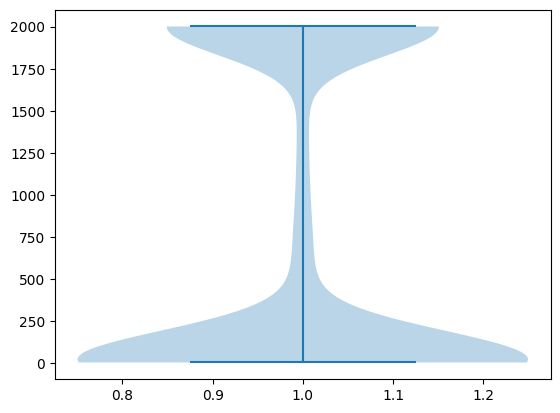

In [10]:
log_dir = "/home/moskit/epfl/legged_robots/quadruped_project/trained_models/flat_terrain/survival_reward_random_vel"
rewards_xy_list, episode_xy_list = extract_results([log_dir] , 10e10, 'timesteps', "test")
analyse_output(episode_xy_list)

1285.5054563405138


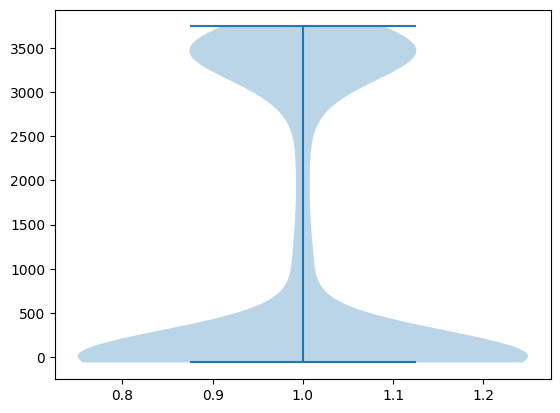

In [11]:
analyse_output(rewards_xy_list)

885.8356890459364


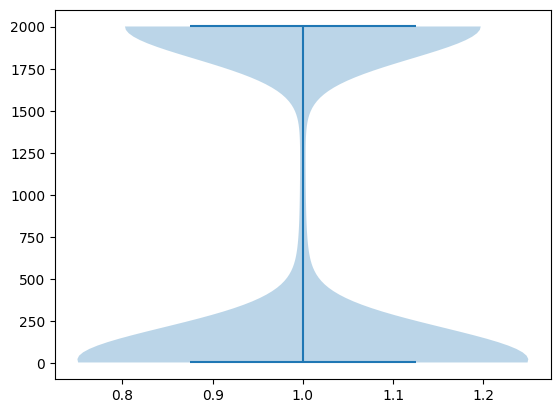

In [13]:
log_dir = "/home/moskit/epfl/legged_robots/quadruped_project/trained_models/flat_terrain/cpg_rl_rand_vel"
rewards_xy_list, episode_xy_list = extract_results([log_dir] , 10e10, 'timesteps', "test")
analyse_output(episode_xy_list)

1286.3941608068317


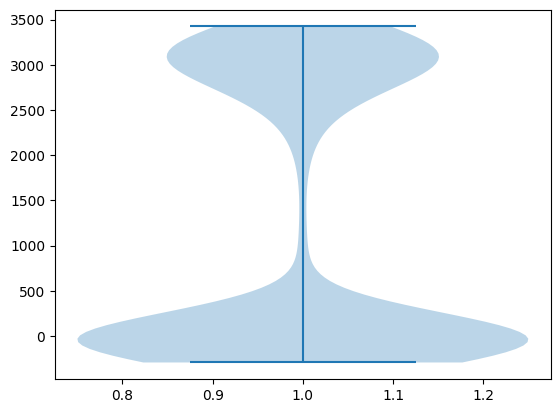

In [14]:
analyse_output(rewards_xy_list)